# California Housing

## Source
This dataset is a modified version of the California Housing dataset available from [Luís Torgo's page](http://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html) (University of Porto). Luís Torgo obtained it from the StatLib repository (which is closed now). The dataset may also be downloaded from StatLib mirrors.

This dataset appeared in a 1997 paper titled *Sparse Spatial Autoregressions* by Pace, R. Kelley and Ronald Barry, published in the *Statistics and Probability Letters* journal. They built it using the 1990 California census data. It contains one row per census block group. A block group is the smallest geographical unit for which the U.S. Census Bureau publishes sample data (a block group typically has a population of 600 to 3,000 people).

## Tweaks
The dataset in this directory is almost identical to the original, with two differences:

* 207 values were randomly removed from the `total_bedrooms` column, so we can discuss what to do with missing data.
* An additional categorical attribute called `ocean_proximity` was added, indicating (very roughly) whether each block group is near the ocean, near the Bay area, inland or on an island. This allows discussing what to do with categorical data.

Note that the block groups are called "districts" in the Jupyter notebooks, simply because in some contexts the name "block group" was confusing.

## Data description

    >>> housing.info()
    <class 'pandas.core.frame.DataFrame'>
    RangeIndex: 20640 entries, 0 to 20639
    Data columns (total 10 columns):
    longitude             20640 non-null float64
    latitude              20640 non-null float64
    housing_median_age    20640 non-null float64
    total_rooms           20640 non-null float64
    total_bedrooms        20433 non-null float64
    population            20640 non-null float64
    households            20640 non-null float64
    median_income         20640 non-null float64
    median_house_value    20640 non-null float64
    ocean_proximity       20640 non-null object
    dtypes: float64(9), object(1)
    memory usage: 1.6+ MB

    >>> housing["ocean_proximity"].value_counts()
    <1H OCEAN     9136
    INLAND        6551
    NEAR OCEAN    2658
    NEAR BAY      2290
    ISLAND           5
    Name: ocean_proximity, dtype: int64

    >>> housing.describe()
              longitude      latitude  housing_median_age   total_rooms  \
    count  16513.000000  16513.000000        16513.000000  16513.000000
    mean    -119.575972     35.639693           28.652335   2622.347605
    std        2.002048      2.138279           12.576306   2138.559393
    min     -124.350000     32.540000            1.000000      6.000000
    25%     -121.800000     33.940000           18.000000   1442.000000
    50%     -118.510000     34.260000           29.000000   2119.000000
    75%     -118.010000     37.720000           37.000000   3141.000000
    max     -114.310000     41.950000           52.000000  39320.000000

           total_bedrooms    population    households  median_income
    count    16355.000000  16513.000000  16513.000000   16513.000000
    mean       534.885112   1419.525465    496.975050       3.875651
    std        412.716467   1115.715084    375.737945       1.905088
    min          2.000000      3.000000      2.000000       0.499900
    25%        295.000000    784.000000    278.000000       2.566800
    50%        433.000000   1164.000000    408.000000       3.541400
    75%        644.000000   1718.000000    602.000000       4.745000
    max       6210.000000  35682.000000   5358.000000      15.000100



In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.graphics.gofplots import qqplot

from utilties.unzip import untar
from utilties import utils

In [37]:
df = pd.read_csv("Housing.csv")

In [38]:
df.shape

(20640, 10)

In [39]:
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [41]:
df["households"]

0         126.0
1        1138.0
2         177.0
3         219.0
4         259.0
          ...  
20635     330.0
20636     114.0
20637     433.0
20638     349.0
20639     530.0
Name: households, Length: 20640, dtype: float64

In [42]:
df["total_bedrooms"].value_counts()

total_bedrooms
280.0     55
331.0     51
345.0     50
343.0     49
393.0     49
          ..
1609.0     1
1591.0     1
2506.0     1
2238.0     1
1052.0     1
Name: count, Length: 1923, dtype: int64

In [43]:
help(utils.unique_values_percentage)

Help on function unique_values_percentage in module utilties.utils:

unique_values_percentage(df, columns)
    A function to calculate the summary of categorical columns of a dataframe
        @param: df -> DataFrame
        @param columns: list of categorical columns in the dataframe
        @returns: dictionary of summary of unique value counts and their percentages
    >>> x = pd.DataFrame({'temp':['hot','hot','cool']})



In [44]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [45]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [46]:
# help(tree.DecisionTreeClassifier)

In [47]:
# help(tree.DecisionTreeRegressor)

In [48]:
from six import StringIO
from sklearn.tree import export_graphviz

# export_graphviz(decision_tree=dt)
out = StringIO()
out.read(1)

''

In [49]:
x = out.write("2")

In [50]:
type(x)

int

## EDA

In [51]:
dfAnalysis = df.copy()
dfAnalysis[["total_bedrooms", "total_rooms"]].corr()

,total_bedrooms,total_rooms
total_bedrooms,1.00000,0.93038
total_rooms,0.93038,1.00000


In [52]:
dummies = pd.get_dummies(dfAnalysis["ocean_proximity"], dtype=int, drop_first=True)
dfAnalysis = pd.concat([dfAnalysis, dummies], axis=1)

In [53]:
dfAnalysis.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0,0,1,0
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY,0,0,1,0
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY,0,0,1,0
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY,0,0,1,0
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY,0,0,1,0
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY,0,0,1,0


In [54]:
dfAnalysis.drop("ocean_proximity", axis=1, inplace=True)
dfAnalysis.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,0,0,1,0
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,0,0,1,0
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,0,0,1,0
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,0,0,1,0
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,0,0,1,0


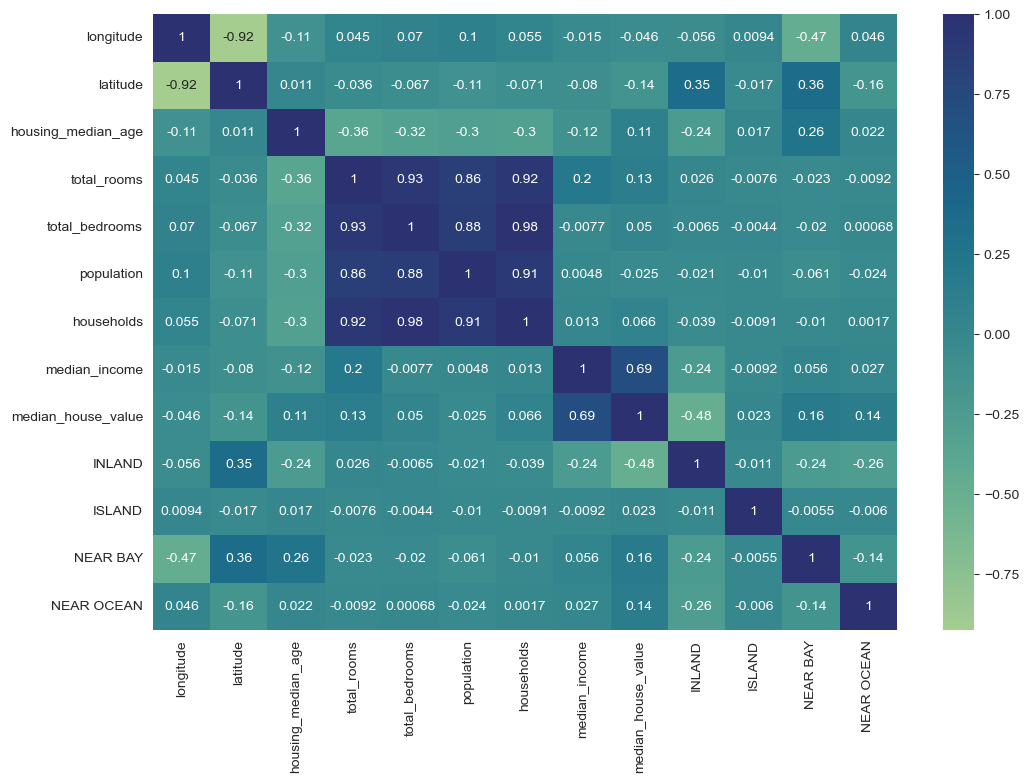

In [55]:
plt.figure(figsize=(12, 8))
sns.heatmap(dfAnalysis.corr(), annot=True, cmap="crest")
plt.show()

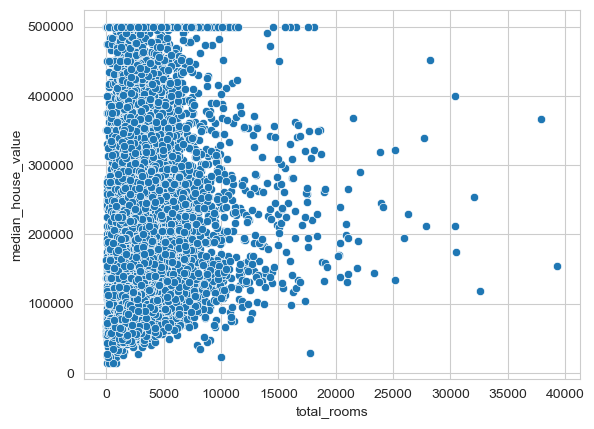

In [56]:
sns.scatterplot(x=dfAnalysis["total_rooms"], y=dfAnalysis["median_house_value"])
plt.show()

In [57]:
dfAnalysis["median_house_value"].describe()

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64

In [58]:
dfAnalysis["total_rooms"].describe()

count    20640.000000
mean      2635.763081
std       2181.615252
min          2.000000
25%       1447.750000
50%       2127.000000
75%       3148.000000
max      39320.000000
Name: total_rooms, dtype: float64

In [59]:
dfAnalysis = dfAnalysis[~dfAnalysis["total_bedrooms"].isna()]

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, RobustScaler

In [61]:
df_train, df_test = train_test_split(dfAnalysis, test_size=0.3, random_state=42)

In [62]:
(df_train.shape, df_test.shape)

((14303, 13), (6130, 13))

In [63]:
scaler = MinMaxScaler()
scaler.fit_transform(df_train)

array([[0.38446215, 0.50690755, 0.8627451 , ..., 0.        , 0.        ,
        0.        ],
       [0.64243028, 0.11689692, 0.52941176, ..., 0.        , 0.        ,
        0.        ],
       [0.19721116, 0.8512221 , 0.49019608, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.64243028, 0.16684378, 0.43137255, ..., 0.        , 0.        ,
        0.        ],
       [0.59661355, 0.1424017 , 0.52941176, ..., 0.        , 0.        ,
        0.        ],
       [0.30478088, 0.5749203 , 1.        , ..., 0.        , 0.        ,
        0.        ]])

In [64]:
X_train = df_train.drop("median_house_value", axis=1)
y_train = df_train["median_house_value"]
X_test = df_test.drop("median_house_value", axis=1)
y_test = df_test["median_house_value"]

In [65]:
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV

lm = LinearRegression()
# create a KFold object with 5 splits
folds = KFold(n_splits=5, shuffle=True, random_state=100)
scores = cross_val_score(lm, X_train, y_train, scoring="r2", cv=folds)
np.mean(scores)

np.float64(0.645463705417882)

In [66]:
from sklearn.linear_model import Ridge

# it will not handle the overfitting
params = {
    "alpha": [
        0.0001,
        0.001,
        0.01,
        0.05,
        0.1,
        0.2,
        0.3,
        0.4,
        0.5,
        0.6,
        0.7,
        0.8,
        0.9,
        1.0,
        2.0,
        3.0,
        4.0,
        5.0,
        6.0,
        7.0,
        8.0,
        9.0,
        10.0,
        20,
        50,
        100,
        500,
        1000,
    ]
}

ridge = Ridge()

# cross validation
folds = 5
model_cv = GridSearchCV(
    estimator=ridge,
    param_grid=params,
    scoring="neg_mean_absolute_error",
    cv=folds,
    return_train_score=True,
    verbose=1,
)
model_cv.fit(X_train, y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3,
                                   0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0,
                                   4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 50,
                                   100, 500, 1000]},
             return_train_score=True, scoring='neg_mean_absolute_error',
             verbose=1)

In [67]:
alpha = 2
lm = Ridge(alpha=alpha)
lm.fit(X_train, y_train)
y_pred = lm.predict(X_test)

In [68]:
y_pred

array([ 91582.18234128, 414161.26266446, 243945.78079885, ...,
       233863.69826844, 295043.83124225, 299992.70177392])

In [69]:
import utilties.utils as utils

utils.goodness_of_fit(y_test, y_pred)

[('Accuracy:', 0.6417447105904609),
 ('RSS:', np.float64(29346125693535.297)),
 ('MSE:', 4787296197.966606),
 ('RMSE:', np.float64(69190.28976645933))]

In [70]:
y_train_pred = lm.predict(X_train)
utils.goodness_of_fit(y_train, y_train_pred)

[('Accuracy:', 0.648212020080039),
 ('RSS:', np.float64(66962651173006.69)),
 ('MSE:', 4681720700.063392),
 ('RMSE:', np.float64(68423.10063175588))]

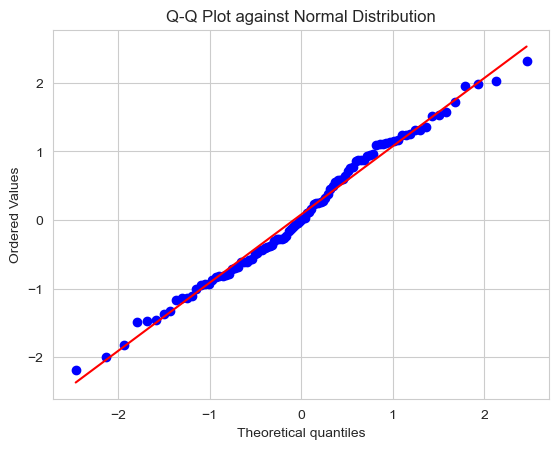

In [73]:
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# Generate some sample data (e.g., from a normal distribution)
data = np.random.normal(loc=0, scale=1, size=100)

# Create a Q-Q plot against a normal distribution
stats.probplot(data, dist="norm", plot=plt)
plt.title("Q-Q Plot against Normal Distribution")
plt.show()

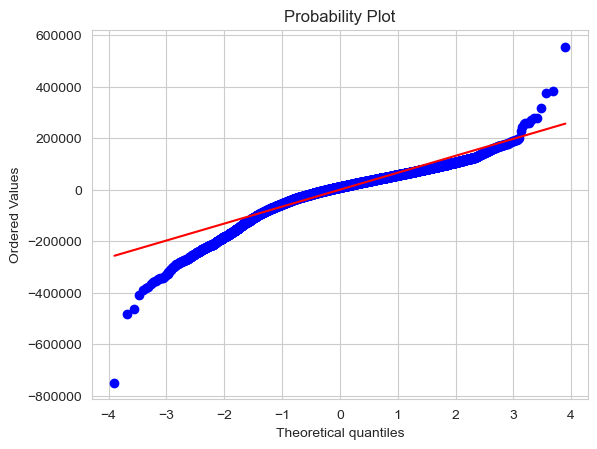

In [79]:
import matplotlib.pyplot as plt

res = y_train_pred - y_train
stats.probplot(res, dist="norm", plot=plt)
plt.show()

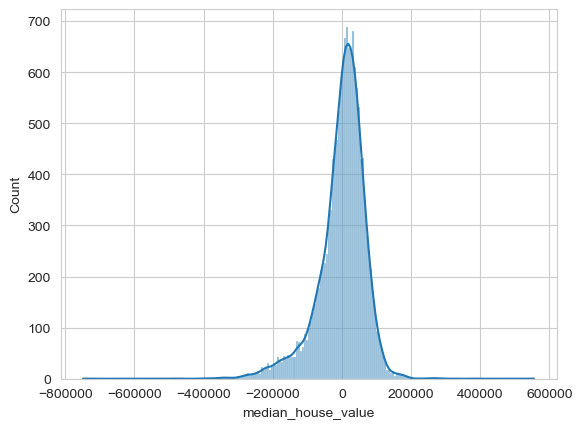

In [80]:
sns.histplot(res, kde=True)
plt.show()

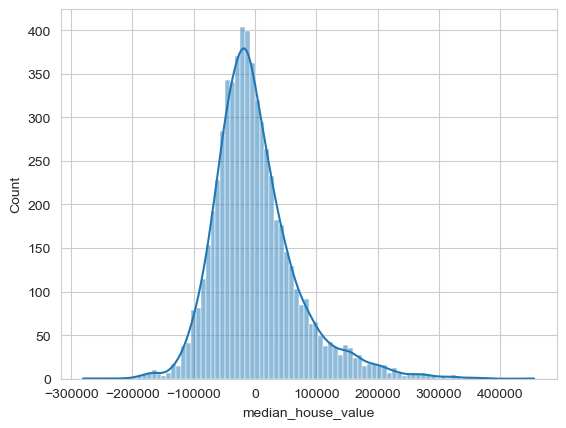

In [81]:
sns.histplot(y_test - y_pred, kde=True)
plt.show()

In [82]:
import numpy as np

rng = np.random.RandomState(42)
x = np.linspace(start=0, stop=10, num=100)
X = x[:, np.newaxis]
y_true_mean = 10 + 0.5 * x
y_normal = y_true_mean + rng.normal(loc=0, scale=0.5 + 0.5 * x, size=x.shape[0])
a = 5
y_pareto = y_true_mean + 10 * (rng.pareto(a, size=x.shape[0]) - 1 / (a - 1))

from sklearn.linear_model import QuantileRegressor

quantiles = [0.05, 0.5, 0.95]
predictions = {}
out_bounds_predictions = np.zeros_like(y_true_mean, dtype=np.bool_)
for quantile in quantiles:
    qr = QuantileRegressor(quantile=quantile, alpha=0)
    y_pred = qr.fit(X, y_normal).predict(X)
    predictions[quantile] = y_pred

    if quantile == min(quantiles):
        out_bounds_predictions = np.logical_or(
            out_bounds_predictions, y_pred >= y_normal
        )
    elif quantile == max(quantiles):
        out_bounds_predictions = np.logical_or(
            out_bounds_predictions, y_pred <= y_normal
        )

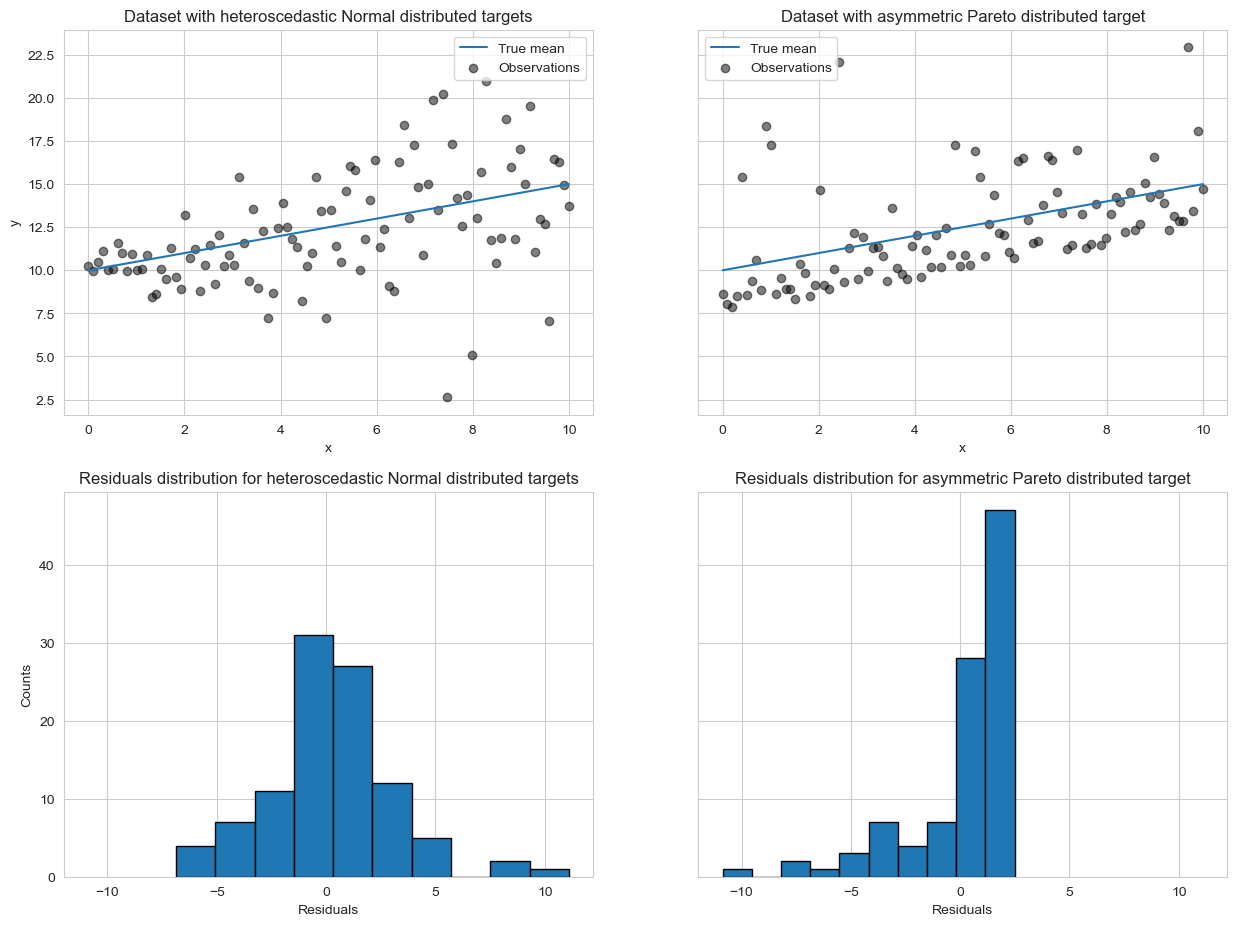

In [83]:
import matplotlib.pyplot as plt

_, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 11), sharex="row", sharey="row")

axs[0, 0].plot(x, y_true_mean, label="True mean")
axs[0, 0].scatter(x, y_normal, color="black", alpha=0.5, label="Observations")
axs[1, 0].hist(y_true_mean - y_normal, edgecolor="black")


axs[0, 1].plot(x, y_true_mean, label="True mean")
axs[0, 1].scatter(x, y_pareto, color="black", alpha=0.5, label="Observations")
axs[1, 1].hist(y_true_mean - y_pareto, edgecolor="black")

axs[0, 0].set_title("Dataset with heteroscedastic Normal distributed targets")
axs[0, 1].set_title("Dataset with asymmetric Pareto distributed target")
axs[1, 0].set_title(
    "Residuals distribution for heteroscedastic Normal distributed targets"
)
axs[1, 1].set_title("Residuals distribution for asymmetric Pareto distributed target")
axs[0, 0].legend()
axs[0, 1].legend()
axs[0, 0].set_ylabel("y")
axs[1, 0].set_ylabel("Counts")
axs[0, 1].set_xlabel("x")
axs[0, 0].set_xlabel("x")
axs[1, 0].set_xlabel("Residuals")
_ = axs[1, 1].set_xlabel("Residuals")

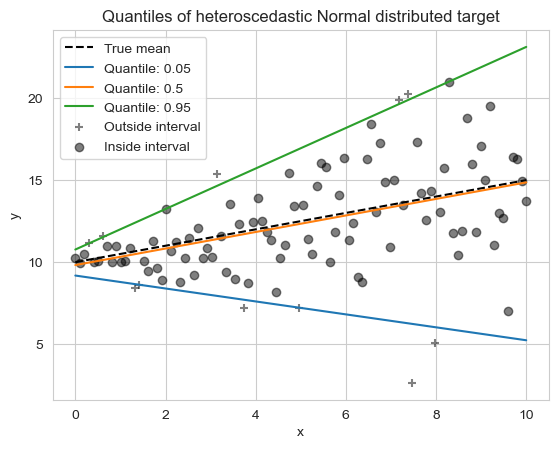

In [84]:
plt.plot(X, y_true_mean, color="black", linestyle="dashed", label="True mean")

for quantile, y_pred in predictions.items():
    plt.plot(X, y_pred, label=f"Quantile: {quantile}")

plt.scatter(
    x[out_bounds_predictions],
    y_normal[out_bounds_predictions],
    color="black",
    marker="+",
    alpha=0.5,
    label="Outside interval",
)
plt.scatter(
    x[~out_bounds_predictions],
    y_normal[~out_bounds_predictions],
    color="black",
    alpha=0.5,
    label="Inside interval",
)

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
_ = plt.title("Quantiles of heteroscedastic Normal distributed target")

In [85]:
quantiles = [0.05, 0.5, 0.95]
predictions = {}
out_bounds_predictions = np.zeros_like(y_true_mean, dtype=np.bool_)
for quantile in quantiles:
    qr = QuantileRegressor(quantile=quantile, alpha=0)
    y_pred = qr.fit(X, y_pareto).predict(X)
    predictions[quantile] = y_pred

    if quantile == min(quantiles):
        out_bounds_predictions = np.logical_or(
            out_bounds_predictions, y_pred >= y_pareto
        )
    elif quantile == max(quantiles):
        out_bounds_predictions = np.logical_or(
            out_bounds_predictions, y_pred <= y_pareto
        )

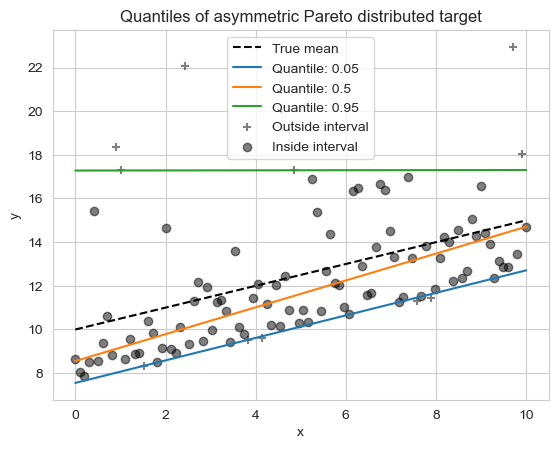

In [86]:
plt.plot(X, y_true_mean, color="black", linestyle="dashed", label="True mean")

for quantile, y_pred in predictions.items():
    plt.plot(X, y_pred, label=f"Quantile: {quantile}")

plt.scatter(
    x[out_bounds_predictions],
    y_pareto[out_bounds_predictions],
    color="black",
    marker="+",
    alpha=0.5,
    label="Outside interval",
)
plt.scatter(
    x[~out_bounds_predictions],
    y_pareto[~out_bounds_predictions],
    color="black",
    alpha=0.5,
    label="Inside interval",
)

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
_ = plt.title("Quantiles of asymmetric Pareto distributed target")

In [89]:
import os
from inspect import getsourcefile

os.path.abspath(getsourcefile(lambda x: x == "housing.ipynb"))

'/var/folders/sn/kqm8k02j2cx8v7fm_56dlzd80000gn/T/ipykernel_2949/3375225471.py'